# D3 — Bank Marketing: Phân lớp + Luật kết hợp

## 1. Nguồn – giấy phép – quy mô

| Mục | Thông tin |
|---|---|
| Dataset | Bank Marketing |
| Link | https://archive.ics.uci.edu/dataset/222/bank+marketing |
| Đơn vị công bố | UCI Machine Learning Repository |
| Tác giả | S. Moro, P. Rita, P. Cortez |
| Giấy phép | CC BY 4.0 |
| Ngày tải/truy cập | 25/08/2026 |
| Quy mô công bố | 45,211 bản ghi, 16 đầu vào + 1 mục tiêu |
| Kỹ thuật yêu cầu | **Phân lớp + Luật kết hợp** |

**Tri thức lĩnh vực:** dữ liệu mô tả các chiến dịch marketing trực tiếp của một ngân hàng Bồ Đào Nha. Mục tiêu là dự đoán khách hàng có đăng ký tiền gửi có kỳ hạn hay không (`y`) nên phù hợp với **phân lớp nhị phân**. Sau khi rời rạc hóa biến số và biến mỗi hồ sơ thành tập item, có thể dùng **luật kết hợp** để khám phá các tổ hợp đặc trưng thường đi cùng với kết quả `y`.

## 2. Từ điển dữ liệu

| Thuộc tính | Ý nghĩa | Kiểu | Thang đo | Miền giá trị chính |
|---|---|---|---|---|
| age | Tuổi | int | tỷ lệ | số nguyên |
| job | Nghề nghiệp | category | danh nghĩa | các nhóm nghề |
| marital | Tình trạng hôn nhân | category | danh nghĩa | married/single/divorced/... |
| education | Học vấn | category | danh nghĩa | các nhóm học vấn |
| default | Nợ tín dụng | category | danh nghĩa | yes/no/unknown |
| balance | Số dư | int | tỷ lệ | số nguyên |
| housing | Vay mua nhà | category | danh nghĩa | yes/no |
| loan | Vay cá nhân | category | danh nghĩa | yes/no |
| contact | Loại liên lạc | category | danh nghĩa | cellular/telephone/unknown |
| day | Ngày liên lạc | int | khoảng | 1..31 |
| month | Tháng liên lạc | category | danh nghĩa | jan..dec |
| duration | Thời lượng cuộc gọi | int | tỷ lệ | giây |
| campaign | Số liên hệ trong chiến dịch | int | tỷ lệ | >= 1 |
| pdays | Ngày từ chiến dịch trước | int | khoảng | giá trị mã hóa/không liên hệ |
| previous | Số liên hệ trước đó | int | tỷ lệ | >= 0 |
| poutcome | Kết quả chiến dịch trước | category | danh nghĩa | success/failure/other/unknown |
| y | Có đăng ký tiền gửi | category | danh nghĩa nhị phân | yes/no |

**Thuộc tính rò rỉ cần chú ý:** `duration` được biết sau khi cuộc gọi diễn ra và ảnh hưởng rất mạnh tới `y`; nếu mục tiêu là dự đoán trước khi gọi thì phải loại `duration`.

In [6]:
import os, warnings, numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from scipy.stats import zscore
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
warnings.filterwarnings("ignore")
os.makedirs("outputs",exist_ok=True); os.makedirs("outputs/figures",exist_ok=True)

bank=fetch_ucirepo(id=222)
X_raw=bank.data.features.copy()
y_raw=bank.data.targets.copy()
df=pd.concat([X_raw,y_raw],axis=1)
print("Shape:",df.shape)
display(df.head())
display(df.dtypes.to_frame("dtype"))

Shape: (45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN,no
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN,no
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,92,1,-1,0,NaN,no
4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,198,1,-1,0,NaN,no


,dtype
age,int64
job,object
marital,object
education,object
default,object
balance,int64
housing,object
loan,object
contact,object
day_of_week,int64


## 3. Khảo sát giá trị thiếu

Kiểm tra theo tỷ lệ từng thuộc tính. UCI ghi nhận dữ liệu chính không có missing theo metadata, nhưng vẫn kiểm tra lại để notebook có thể phát hiện thay đổi hoặc lỗi tải. Các giá trị `unknown` là **một mức danh mục**, không tự động đổi thành NaN trừ khi mục tiêu phân tích yêu cầu.

In [7]:
missing=pd.DataFrame({
    "missing_count":df.isna().sum(),
    "missing_percent":(df.isna().mean()*100).round(2)
}).sort_values("missing_percent",ascending=False)
display(missing)
missing.to_csv("outputs/missing_report.csv",encoding="utf-8-sig")

,missing_count,missing_percent
poutcome,36959,81.75
contact,13020,28.80
education,1857,4.11
job,288,0.64
age,0,0.00
default,0,0.00
balance,0,0.00
housing,0,0.00
marital,0,0.00
loan,0,0.00


## 4. Nhiễu/ngoại lai: IQR + Z-score + Boxplot

Kiểm tra các biến số. Các giá trị cực trị như số dư, thời lượng hoặc số lần liên hệ có thể là khách hàng thật; do đó không xóa tự động. Với các biến lệch phải có thể dùng `log1p` trong bước biến đổi. `duration` còn được xem xét riêng như biến leakage theo thời điểm dự đoán.

,attribute,Q1,Q3,IQR,lower,upper,IQR_count,IQR_percent,Zscore_count
0,age,33.0,48.0,15.0,10.5,70.5,487,1.08,381
1,balance,72.0,1428.0,1356.0,-1962.0,3462.0,4729,10.46,745
2,day_of_week,8.0,21.0,13.0,-11.5,40.5,0,0.00,0
3,duration,103.0,319.0,216.0,-221.0,643.0,3235,7.16,963
4,campaign,1.0,3.0,2.0,-2.0,6.0,3064,6.78,840
5,pdays,-1.0,-1.0,0.0,-1.0,-1.0,8257,18.26,1723
6,previous,0.0,0.0,0.0,0.0,0.0,8257,18.26,582


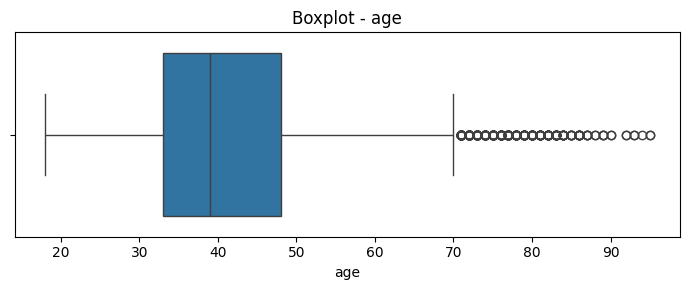

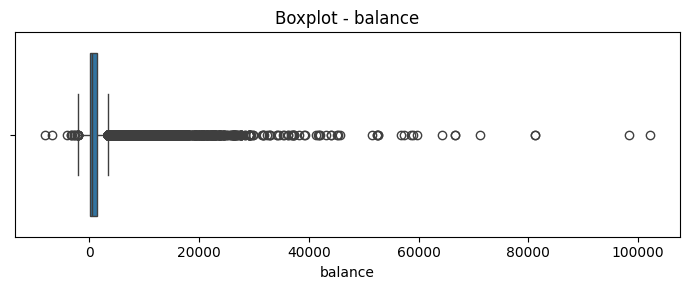

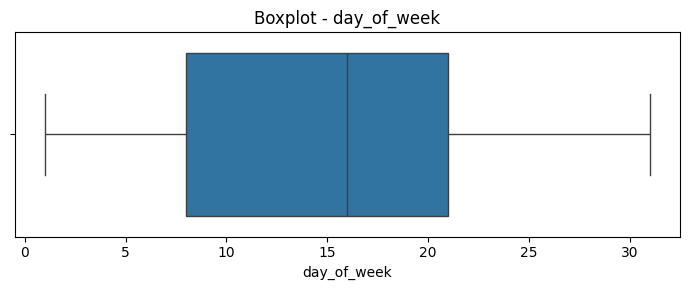

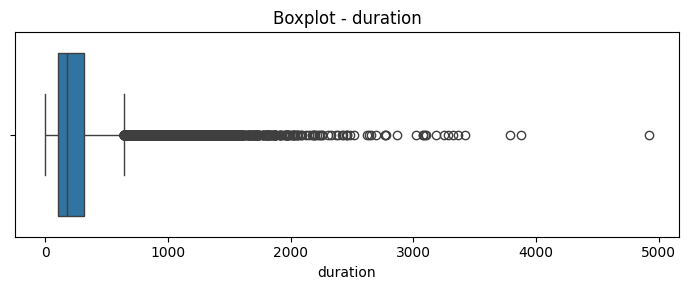

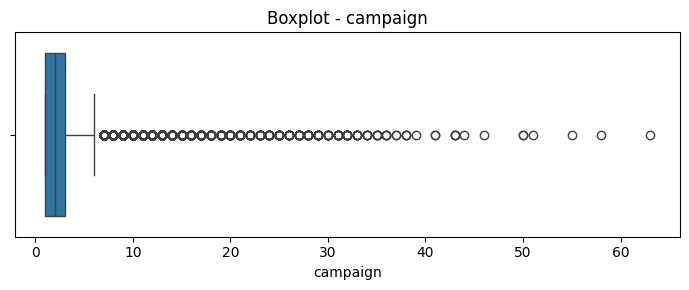

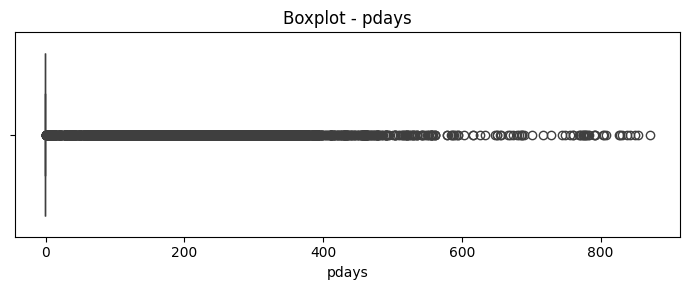

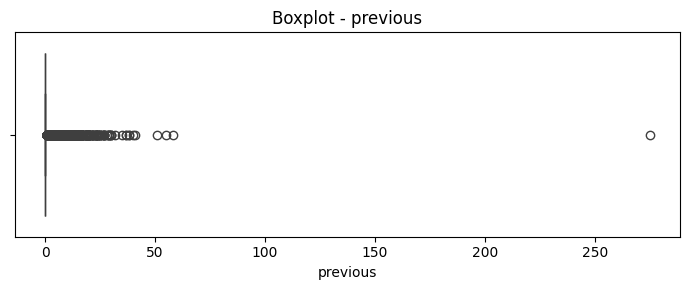

In [8]:
num_cols=df.select_dtypes(include=["int64","float64"]).columns.tolist()
rows=[]
for c in num_cols:
    s=pd.to_numeric(df[c],errors="coerce").dropna()
    if len(s)==0: continue
    q1,q3=s.quantile(.25),s.quantile(.75); iqr=q3-q1
    lo,hi=q1-1.5*iqr,q3+1.5*iqr
    iqr_n=((s<lo)|(s>hi)).sum()
    z_n=(np.abs(zscore(s))>3).sum() if s.std()!=0 else 0
    rows.append([c,q1,q3,iqr,lo,hi,int(iqr_n),round(iqr_n/len(s)*100,2),int(z_n)])
outliers=pd.DataFrame(rows,columns=["attribute","Q1","Q3","IQR","lower","upper","IQR_count","IQR_percent","Zscore_count"])
display(outliers)
outliers.to_csv("outputs/outlier_report.csv",index=False,encoding="utf-8-sig")

for c in num_cols:
    plt.figure(figsize=(7,3)); sns.boxplot(x=df[c])
    plt.title(f"Boxplot - {c}"); plt.tight_layout()
    plt.savefig(f"outputs/figures/boxplot_{c}.png",dpi=120); plt.show()

## 5. Đề xuất thêm/xóa/biến đổi thuộc tính

- **Loại leakage theo kịch bản dự đoán trước cuộc gọi:** `duration`.
- `y` chỉ là biến mục tiêu, không dùng làm feature.
- Mã hóa One-Hot cho biến danh nghĩa.
- Median cho biến số nếu phát sinh missing; mode cho biến phân loại.
- Có thể log-transform `balance`, `campaign`, `previous` khi phân phối lệch.
- Tạo nhóm tuổi `AgeGroup` để dùng trong luật kết hợp.
- Với luật kết hợp, rời rạc hóa biến số và tiền tố hóa item để tránh nhầm giữa các miền.

## 6. Thực nghiệm 1 — Phân lớp

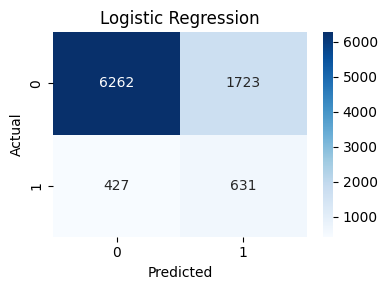

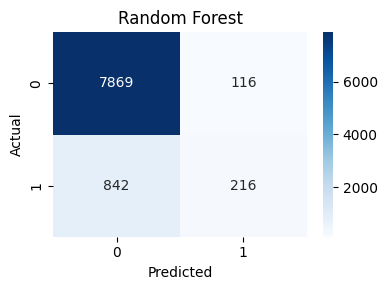

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.762247,0.268054,0.596408,0.369871,0.751777
1,Random Forest,0.894062,0.650602,0.204159,0.310791,0.780678


In [9]:
# Kịch bản dự đoán trước khi gọi: loại duration để tránh leakage
X=df.drop(columns=["y","duration"],errors="ignore")
y=(df["y"].astype(str).str.lower()=="yes").astype(int)

num_features=X.select_dtypes(include=["int64","float64"]).columns.tolist()
cat_features=[c for c in X.columns if c not in num_features]

pre=ColumnTransformer([
    ("num",Pipeline([("imputer",SimpleImputer(strategy="median")),("scaler",StandardScaler())]),num_features),
    ("cat",Pipeline([("imputer",SimpleImputer(strategy="most_frequent")),("oh",OneHotEncoder(handle_unknown="ignore"))]),cat_features)
])

Xtr,Xte,ytr,yte=train_test_split(X,y,test_size=.2,random_state=42,stratify=y)
models={
    "Logistic Regression":LogisticRegression(max_iter=3000,class_weight="balanced",random_state=42),
    "Random Forest":RandomForestClassifier(n_estimators=300,class_weight="balanced",random_state=42)
}
results=[]
for name,model in models.items():
    pipe=Pipeline([("pre",pre),("model",model)])
    pipe.fit(Xtr,ytr); pred=pipe.predict(Xte); prob=pipe.predict_proba(Xte)[:,1]
    results.append({
        "Model":name,
        "Accuracy":accuracy_score(yte,pred),
        "Precision":precision_score(yte,pred,zero_division=0),
        "Recall":recall_score(yte,pred,zero_division=0),
        "F1":f1_score(yte,pred,zero_division=0),
        "ROC_AUC":roc_auc_score(yte,prob)
    })
    cm=confusion_matrix(yte,pred)
    plt.figure(figsize=(4,3)); sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")
    plt.title(name); plt.xlabel("Predicted"); plt.ylabel("Actual")
    plt.tight_layout(); plt.savefig(f"outputs/figures/cm_{name.replace(' ','_')}.png",dpi=140); plt.show()

cls_results=pd.DataFrame(results).sort_values("F1",ascending=False)
display(cls_results)
cls_results.to_csv("outputs/classification_results.csv",index=False,encoding="utf-8-sig")

## 7. Thực nghiệm 2 — Luật kết hợp

Mỗi khách hàng được chuyển thành một tập item:
- Biến phân loại: `job=...`, `housing=...`, ...
- Biến số: chia thành nhóm như `age=Q1-Q2`, `balance=...`
- Biến mục tiêu được đưa thành item `TARGET=yes/no` để có thể lọc các luật dự báo/diễn giải hướng tới kết quả.

Để giảm chi phí, có thể lấy mẫu tái lập khi chạy trên máy yếu.

In [10]:
rule_df=df.copy()
if len(rule_df)>20000:
    rule_df=rule_df.sample(20000,random_state=42).copy()

# Rời rạc hóa các biến số chính bằng quantile; tránh lỗi nếu ít giá trị
for c in ["age","balance","campaign","previous","pdays"]:
    if c in rule_df.columns:
        try:
            rule_df[c+"_bin"]=pd.qcut(rule_df[c],q=4,duplicates="drop").astype(str)
        except Exception:
            rule_df[c+"_bin"]=pd.cut(rule_df[c],bins=4).astype(str)

selected=[c for c in rule_df.columns if rule_df[c].dtype=="object" or c.endswith("_bin")]
selected=[c for c in selected if c not in ["y"]]

transactions=[]
for _,row in rule_df.iterrows():
    items=[f"{c}={row[c]}" for c in selected if pd.notna(row[c])]
    items.append(f"TARGET={row['y']}")
    transactions.append(items)

te=TransactionEncoder()
basket=pd.DataFrame(te.fit(transactions).transform(transactions),columns=te.columns_)

freq=apriori(basket,min_support=0.03,use_colnames=True)
rules=association_rules(freq,metric="confidence",min_threshold=0.5)

# Chỉ giữ luật có consequent chứa TARGET=yes để dễ diễn giải
target_yes=rules[rules["consequents"].apply(lambda s:"TARGET=yes" in s)].copy()
target_yes=target_yes[target_yes["lift"]>1].sort_values(["lift","confidence"],ascending=False)

display(freq.sort_values("support",ascending=False).head(25))
display(target_yes[["antecedents","consequents","support","confidence","lift"]].head(30))
freq.to_csv("outputs/frequent_itemsets.csv",index=False,encoding="utf-8-sig")
target_yes.to_csv("outputs/association_rules_target_yes.csv",index=False,encoding="utf-8-sig")

MemoryError: Unable to allocate 546. MiB for an array with shape (9547, 3, 20000) and data type bool

## 8. Kết luận D3

- **Phân lớp phù hợp** vì `y` là nhãn yes/no.
- **Luật kết hợp phù hợp** sau khi biến mỗi hồ sơ thành tập item rời rạc.
- `duration` được loại trong kịch bản dự đoán trước cuộc gọi vì đây là thuộc tính leakage theo thời điểm.
- Ngoại lai được xem xét bằng IQR, Z-score và boxplot nhưng chỉ loại khi có bằng chứng lỗi.
- Kết quả luật được đọc cùng support, confidence, lift; luật không đồng nghĩa với quan hệ nhân quả.